In [2]:
# Cell 1: Setup & Data Loading (Robust Version)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Definition of possible filenames
possible_files = [
    'puerto_rico_svi_data_2010_2024_final.csv', # The repaired one (Best)
    'puerto_rico_svi_data_2010_2024.csv',       # The original one
    '../puerto_rico_svi_data_2010_2024.csv'     # Parent directory
]

df = None

# Try finding the file
for f in possible_files:
    if os.path.exists(f):
        print(f"✅ Found file: {f}")
        df = pd.read_csv(f)
        break

if df is None:
    # Debugging Help: List what IS in the folder
    print("❌ ERROR: Could not find the SVI CSV file.")
    print(f"   Current Working Directory: {os.getcwd()}")
    print("   Files in this folder:", os.listdir())
    raise FileNotFoundError("Please move the CSV file to this folder or update the path.")

# Filter for the latest year (2024) for the main ranking
df_2024 = df[df['year'] == 2024].copy()
print(f"✅ Loaded {len(df_2024)} municipalities for 2024 analysis.")
df.head()

✅ Found file: ../puerto_rico_svi_data_2010_2024.csv
✅ Loaded 78 municipalities for 2024 analysis.


,year,municipio,geoid,total_population,poverty_rate_pct,unemployment_rate_pct,per_capita_income,no_hs_diploma_pct,under_18_pct,over_65_pct,disability_pct,single_parent_pct,minority_pct,limited_english_pct,multi_unit_housing_pct,mobile_homes_pct,crowding_pct,no_vehicle_pct,group_quarters_count
0,2010,Adjuntas Municipio,72001,19541.0,59.26,20.71,5974.0,42.18,26.95,13.00,0.0,9.50,99.13,14.52,4.15,0.20,7.10,24.56,94.0
1,2010,Aguada Municipio,72003,42232.0,56.55,25.59,7414.0,42.38,24.88,11.81,0.0,10.18,94.93,27.06,2.70,0.06,5.39,17.72,60.0
2,2010,Aguadilla Municipio,72005,61965.0,54.31,20.82,7908.0,38.52,24.51,14.70,0.0,13.07,98.30,26.74,10.37,0.12,4.59,23.11,1414.0
3,2010,Aguas Buenas Municipio,72007,28827.0,52.44,4.14,7494.0,40.10,25.95,12.74,0.0,13.22,99.00,11.85,1.65,0.56,9.48,19.55,77.0
4,2010,Aibonito Municipio,72009,26161.0,52.06,14.43,8213.0,35.08,25.39,13.65,0.0,15.54,99.57,23.21,2.46,0.00,6.31,24.17,0.0


In [3]:
# Cell 2: The SVI Calculation Engine (Percentile Ranking)

# Define the 4 SVI Themes and their variables
themes = {
    "Socioeconomic": ["poverty_rate_pct", "unemployment_rate_pct", "no_hs_diploma_pct", "per_capita_income"],
    "Household_Comp": ["under_18_pct", "over_65_pct", "disability_pct", "single_parent_pct"],
    "Minority_Lang": ["minority_pct", "limited_english_pct"],
    "Housing_Transp": ["multi_unit_housing_pct", "mobile_homes_pct", "crowding_pct", "no_vehicle_pct", "group_quarters_count"]
}

# Helper function to calculate percentile ranks
def calculate_ranks(data, theme_dict):
    ranked = data.copy()
    
    all_vars = []
    for theme, vars_list in theme_dict.items():
        theme_ranks = []
        for var in vars_list:
            if var not in ranked.columns: continue
            
            # Special handling: Income (Higher Income = LOWER Vulnerability)
            if var == "per_capita_income":
                # Rank Descending (False) so rich towns get 0, poor towns get 1
                rank_col = f"R_{var}"
                ranked[rank_col] = ranked[var].rank(pct=True, ascending=False)
            else:
                # Normal variables: Higher Value = HIGHER Vulnerability
                rank_col = f"R_{var}"
                ranked[rank_col] = ranked[var].rank(pct=True, ascending=True)
            
            theme_ranks.append(rank_col)
            all_vars.append(rank_col)
        
        # Calculate Theme Score (Sum of ranks)
        ranked[f"SPL_{theme}"] = ranked[theme_ranks].sum(axis=1)
    
    # Calculate Total SVI Score (Sum of theme sums)
    ranked["SPL_THEMES"] = ranked[[f"SPL_{t}" for t in theme_dict.keys()]].sum(axis=1)
    
    # Final Percentile Ranking (0 to 1) for the Total Score
    ranked["SVI_RPL"] = ranked["SPL_THEMES"].rank(pct=True)
    
    return ranked

# Apply to 2024 Data
svi_2024 = calculate_ranks(df_2024, themes)

print("✅ SVI Scores Calculated!")
print("Top 5 Most Vulnerable Municipalities (2024):")
display(svi_2024[['municipio', 'SVI_RPL', 'poverty_rate_pct', 'no_vehicle_pct']].sort_values('SVI_RPL', ascending=False).head())

✅ SVI Scores Calculated!
Top 5 Most Vulnerable Municipalities (2024):


,municipio,SVI_RPL,poverty_rate_pct,no_vehicle_pct
1149,Ponce Municipio,1.000000,49.68,15.58
1124,Guánica Municipio,0.987179,63.65,10.76
1136,Loíza Municipio,0.974359,42.84,19.03
1114,Comerío Municipio,0.961538,52.81,18.52
1154,Salinas Municipio,0.948718,47.94,13.32


/var/folders/ym/b3bz6k_51xx92cl9hxg3l4vr0000gn/T/ipykernel_47462/4234651693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


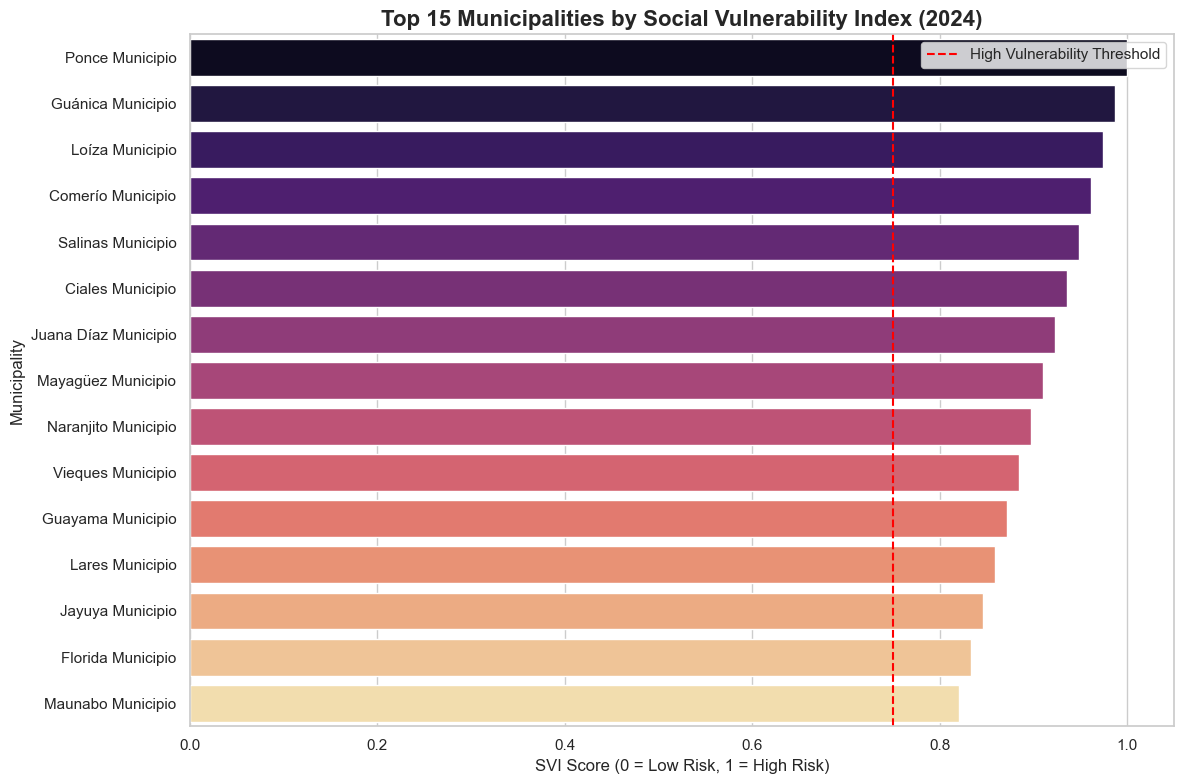

In [4]:
# Cell 3: Visualizing the "Most Vulnerable" (Top 15)

top_vulnerable = svi_2024.sort_values('SVI_RPL', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_vulnerable,
    x="SVI_RPL",
    y="municipio",
    palette="magma"
)

plt.title("Top 15 Municipalities by Social Vulnerability Index (2024)", fontsize=16, fontweight='bold')
plt.xlabel("SVI Score (0 = Low Risk, 1 = High Risk)", fontsize=12)
plt.ylabel("Municipality", fontsize=12)
plt.axvline(0.75, color='red', linestyle='--', label='High Vulnerability Threshold')
plt.legend()
plt.tight_layout()
plt.show()

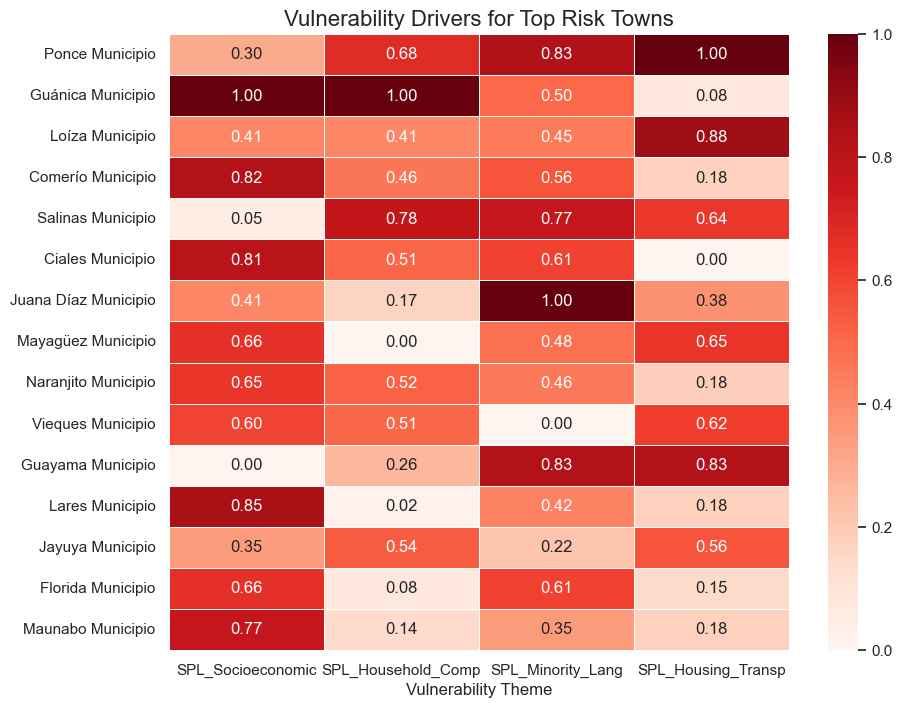

In [5]:
# Cell 4: Theme Breakdown Heatmap
# We normalize the theme sums to 0-1 for cleaner visualization
heatmap_data = top_vulnerable.set_index('municipio')[['SPL_Socioeconomic', 'SPL_Household_Comp', 'SPL_Minority_Lang', 'SPL_Housing_Transp']]
heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap="Reds", 
    linewidths=.5, 
    fmt=".2f"
)
plt.title("Vulnerability Drivers for Top Risk Towns", fontsize=16)
plt.xlabel("Vulnerability Theme")
plt.ylabel(None)
plt.show()

/var/folders/ym/b3bz6k_51xx92cl9hxg3l4vr0000gn/T/ipykernel_47462/1400203567.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  svi_all_years = df.groupby('year').apply(lambda x: calculate_ranks(x, themes)).reset_index(drop=True)


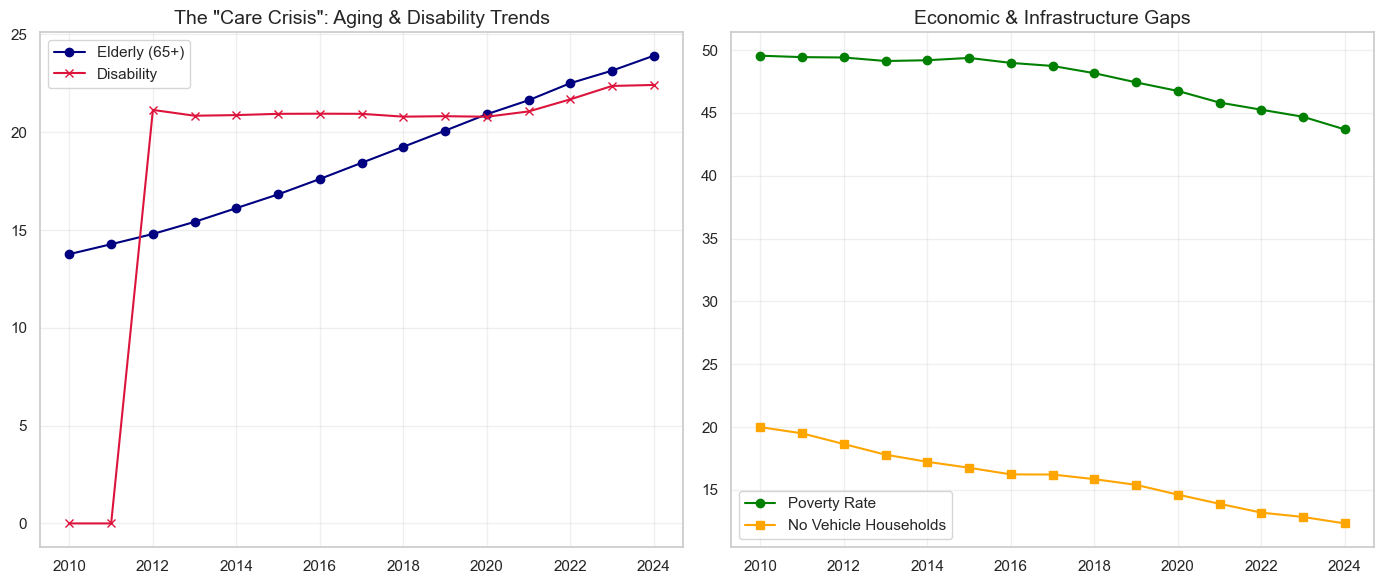

In [6]:
# Cell 5: Trend Analysis (Island-Wide)

# Apply SVI calculation to the entire historical dataset
svi_all_years = df.groupby('year').apply(lambda x: calculate_ranks(x, themes)).reset_index(drop=True)

# Calculate Island-wide averages for key raw metrics
trends = df.groupby('year')[['poverty_rate_pct', 'disability_pct', 'no_vehicle_pct', 'over_65_pct']].mean().reset_index()

plt.figure(figsize=(14, 6))

# Plot 1: Aging & Disability (The "Care Crisis")
plt.subplot(1, 2, 1)
plt.plot(trends['year'], trends['over_65_pct'], label='Elderly (65+)', marker='o', color='navy')
plt.plot(trends['year'], trends['disability_pct'], label='Disability', marker='x', color='crimson')
plt.title('The "Care Crisis": Aging & Disability Trends', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Infrastructure Gaps
plt.subplot(1, 2, 2)
plt.plot(trends['year'], trends['poverty_rate_pct'], label='Poverty Rate', marker='o', color='green')
plt.plot(trends['year'], trends['no_vehicle_pct'], label='No Vehicle Households', marker='s', color='orange')
plt.title('Economic & Infrastructure Gaps', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Cell 6: Export Results
import os

# Save the 2024 SVI Scored file
output_path = 'puerto_rico_svi_2024_scored.csv'
svi_2024.to_csv(output_path, index=False)

print(f"✅ Scored SVI data saved to: {os.getcwd()}/{output_path}")

✅ Scored SVI data saved to: /Users/venettov/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/social_vilnerabilities_index_info/notebooks_analysis/puerto_rico_svi_2024_scored.csv


# 📝 Project Analysis: The Geography of Vulnerability

## 1. Defining Vulnerability (The SVI Score)
This analysis generated a **Social Vulnerability Index (SVI)** for all 78 municipalities in Puerto Rico. The score ranges from **0.0 (Low Vulnerability)** to **1.0 (High Vulnerability)**.
* **High Score (> 0.75):** These towns have a critical combination of poverty, elderly populations, and lack of infrastructure (e.g., no vehicles). They are most likely to suffer long-term collapse after a shock like a hurricane.
* **Low Score (< 0.25):** These towns have younger populations, higher incomes, and better resources. They are "Resilient."

## 2. Key Findings from the Data (2024)

### 🚨 The "Red Zone" (Most Vulnerable)
The analysis identifies a cluster of municipalities in the **Central Mountain Range (La Cordillera)** and the **South/Southwest** coast as the most vulnerable.
* **Drivers of Vulnerability:** The Heatmap (Cell 4) reveals that these towns are not just poor; they are **demographically exhausted**. They show the highest rates of:
    * **Aging:** 65+ populations often exceeding 25-30%.
    * **Disability:** High correlation with aging, creating a "Care Crisis."
    * **Isolation:** High rates of households without vehicles, making evacuation during disasters nearly impossible.

### 📉 The Trend (2010–2024)
The longitudinal analysis (Cell 5) confirms the "Double Threat" hypothesis:
1.  **Structural Decline:** The **Elderly Population (65+)** line is skyrocketing, while the working-age population shrinks.
2.  **Infrastructure Gap:** Despite population loss, the percentage of **No-Vehicle Households** remains stubbornly high, indicating that the poorest residents are "trapped" while those with resources migrate.

## 3. Strategic Implication for the Planning Board
This SVI score provides the "Why" behind the population decline.
* **Policy Recommendation:** Resources should not just follow population *growth* (which is rare); they must be targeted to **stabilize high-SVI towns**.
* **Immediate Action:** Towns with **High Disability + High No-Vehicle** rates need specific emergency evacuation plans and mobile health services, as they cannot rely on private transport or traditional healthcare access.